## practicle 1

### Build a model to classify emails as spam or not spam using a small, labelled dataset.

### import library

In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix


## Reading dataset

In [3]:
data = pd.read_csv('email.csv')  

In [6]:
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
data.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


## changing message in lowercase

In [11]:
data['Message'] = data['Message'].str.lower() 

In [13]:
data.head()

,Category,Message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## getting unique value

In [16]:
data["Category"].unique()

array(['ham', 'spam', '{"mode":"full"'], dtype=object)

## converting "ham" and "spam" to 0 and 1

In [19]:
data['Category'] = data['Category'].map({'spam': 1, 'ham': 0})

## checking for null values

In [22]:
data.isnull().sum()

Category    1
Message     0
dtype: int64

## droping null values in Category column

In [25]:
data= data.dropna(subset=['Category'])

In [27]:
data.isnull().sum()

Category    0
Message     0
dtype: int64

## splitting data into training and testing

In [30]:
X_train, X_test, y_train, y_test = train_test_split(data['Message'], data['Category'], test_size=0.2, random_state=42)

## transforming text data into numerical representations suitable for machine learning algorithms.

In [33]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


## model Selection

In [36]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

## prediction , confusion matrix and classification

In [39]:
y_pred = model.predict(X_test_tfidf)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[966   0]
 [ 26 123]]
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       966
         1.0       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## final 01

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
data = pd.read_csv('email.csv')
data['Message'] = data['Message'].str.lower()
data['Category'] = data['Category'].map({'spam': 1, 'ham': 0})
data= data.dropna(subset=['Category'])
X_train,X_test,y_train,y_test = train_test_split(data['Message'], data['Category'], test_size=0.2, random_state=42)
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[966   0]
 [ 26 123]]
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       966
         1.0       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# Practical 02

### Develop and implement an algorithm to predict house prices based on the number of bedrooms in a dataset of real estate listings.   Determine all the performance metrics.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics


## Reading data


In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## creating new dataset from old one as only price and num of bedroom needed

In [11]:
newdf = df[["price","bedrooms"]]

In [13]:
newdf.head()

,price,bedrooms
0,13300000,4
1,12250000,4
2,12250000,3
3,12215000,4
4,11410000,4


## checking for null values

In [16]:
newdf.isnull().sum()

price       0
bedrooms    0
dtype: int64

## spliting the dataset int train and test data

In [19]:
X = newdf.drop(['price'], axis=1)
Y = newdf['price']

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

## model selection (Linear regression)

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

## model fitting

In [27]:
model.fit(X_train,Y_train)

LinearRegression()

## predictinng the price on basis of test data

In [30]:
Y_predict = model.predict(X_test)

## performance metrics. on basis of predicted values and y_test(actual values)

### R Squared Error




In [38]:
score_1 = metrics.r2_score(Y_test, Y_predict)

### Mean Absolute Error


In [ ]:
score_2 = metrics.mean_absolute_error(Y_test, Y_predict)


### Mean Squared Error

In [150]:
score_3 = metrics.mean_squared_error(Y_test, Y_predict)

In [152]:

print('Mean Squared Error:', score_3)

print('R Sqaured Error:', score_1)
print('Mean Absolute Error:', score_2)

Mean Squared Error: 2771299476021.4663
R Sqaured Error: 0.2191488608889408
Mean Absolute Error: 1226760.05464115


## final 02

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
df = pd.read_csv("Housing.csv")
newdf = df[["price","bedrooms"]]
X = newdf.drop(['price'], axis=1)
Y = newdf['price']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,Y_train)
Y_predict = model.predict(X_test)
score_1 = metrics.r2_score(Y_test, Y_predict)
score_2 = metrics.mean_absolute_error(Y_test, Y_predict)
score_3 = metrics.mean_squared_error(Y_test, Y_predict)
print('Mean Squared Error:', score_3)
print('R Sqaured Error:', score_1)
print('Mean Absolute Error:', score_2)


Mean Squared Error: 2771299476021.4663
R Sqaured Error: 0.2191488608889408
Mean Absolute Error: 1226760.05464115


# Practical 03
### Use the Iris dataset to classify iris flowers into three species. Determine all the performance metrics.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [2]:
iris = load_iris()

#### Features

In [4]:
X = iris.data  # Features

 #### Labels (species)

In [9]:
y = iris.target 

#### splitting data into test and tarin data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Create a SVM classifier

In [15]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42)

### Train the classifier

In [18]:
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)

SVC(kernel='linear', random_state=42)

### Make predictions on the test set

In [21]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Performance metrices
#### Accuracy
#### Precision, Recall, and F1 Score
#### Confusion Matrix
#### Classification Report
#### Print performance metrics


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [26]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### final 03

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X = iris.data
y = iris.target  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# practical 04
## Develop and implement an algorithm to classify fruits based on color and size. Determine all the performance metrics.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

### Loading dataset

In [3]:
df = pd.read_csv("fruits.csv")

In [4]:
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


## droping fruit_label fruit_subtype  as only  color  size mass fruitName  is needed

In [6]:
df =df.drop(['fruit_label','fruit_subtype'],axis = 1)

In [7]:
df.head()

,fruit_name,mass,width,height,color_score
0,apple,192,8.4,7.3,0.55
1,apple,180,8.0,6.8,0.59
2,apple,176,7.4,7.2,0.60
3,mandarin,86,6.2,4.7,0.80
4,mandarin,84,6.0,4.6,0.79


## splitting dataset

In [14]:
X = df.drop(["fruit_name"],axis= 1)

In [16]:
Y = df["fruit_name"]

#### splitting data into test and tarin data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [21]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42)

### Train the classifier

In [24]:
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)

SVC(kernel='linear', random_state=42)

### Make predictions on the test set

In [27]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Performance metrices
#### Accuracy
#### Precision, Recall, and F1 Score
#### Confusion Matrix
#### Classification Report
#### Print performance metrics


In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [32]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.78
Precision: 0.82
Recall: 0.78
F1 Score: 0.79
Confusion Matrix:
[[3 0 0 2]
 [0 4 0 1]
 [0 0 4 0]
 [1 0 0 3]]
Classification Report:
              precision    recall  f1-score   support

       apple       0.75      0.60      0.67         5
       lemon       1.00      0.80      0.89         5
    mandarin       1.00      1.00      1.00         4
      orange       0.50      0.75      0.60         4

    accuracy                           0.78        18
   macro avg       0.81      0.79      0.79        18
weighted avg       0.82      0.78      0.79        18



## final

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
df = pd.read_csv("fruits.csv")
df =df.drop(['fruit_label','fruit_subtype'],axis = 1)
X = df.drop(["fruit_name"],axis= 1)
Y = df["fruit_name"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)


Accuracy: 0.78
Precision: 0.82
Recall: 0.78
F1 Score: 0.79
Confusion Matrix:
[[3 0 0 2]
 [0 4 0 1]
 [0 0 4 0]
 [1 0 0 3]]
Classification Report:
              precision    recall  f1-score   support

       apple       0.75      0.60      0.67         5
       lemon       1.00      0.80      0.89         5
    mandarin       1.00      1.00      1.00         4
      orange       0.50      0.75      0.60         4

    accuracy                           0.78        18
   macro avg       0.81      0.79      0.79        18
weighted avg       0.82      0.78      0.79        18



# practical 05
## Develop and implement an SVM for the classification of the linearly separable and inseparable datasets. Determine all the performance metrics.


## load dataset

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report 
iris = load_iris()



### split dataset

In [3]:
X = iris.data
Y = iris.target  
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [4]:
from sklearn.svm import SVC

# Create a linear SVM classifier

In [6]:
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)

SVC(kernel='linear', random_state=42)

## prediction

In [9]:
y_pred = classifier.predict(X_test)

## Performance metrices of linear SVM classifier
#### Accuracy
#### Precision, Recall, and F1 Score
#### Confusion Matrix
#### Classification Report



In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


In [17]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# Create a nonlinear SVM for inseparable data
try different kernels (e.g., 'rbf', 'poly')

In [20]:
clf_nonlinear = SVC(kernel='rbf') 
clf_nonlinear.fit(X_train, y_train)


SVC()

### prediction

In [23]:
y_pred = clf_nonlinear.predict(X_test) 

## Performance metrices of non linear SVM classifier
#### Accuracy
#### Precision, Recall, and F1 Score
#### Confusion Matrix
#### Classification Report



In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [28]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## final 05

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report 
iris = load_iris()
X = iris.data
Y = iris.target  
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)
SVC(kernel='linear', random_state=42)
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("linear SVM classifier \n")
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)
clf_nonlinear = SVC(kernel='rbf') 
clf_nonlinear.fit(X_train, y_train)
y_pred = clf_nonlinear.predict(X_test) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("\nNon linear SVM classifier\n")
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

linear SVM classifier 

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Non linear SVM classifier

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.

Silhouette Score:  0.6596332095691734
Davies-Bouldin Score:  0.47564935578825746
Confusion Matrix:
 [[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



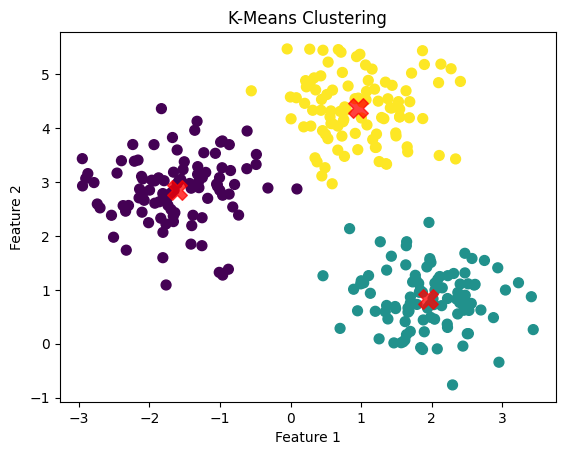

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
X, y_true = datasets.make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(X)
silhouette_avg = silhouette_score(X, y_kmeans)
davies_bouldin = davies_bouldin_score(X, y_kmeans)
print("Silhouette Score: ", silhouette_avg)
print("Davies-Bouldin Score: ", davies_bouldin)

def relabel_clusters(y_true, y_pred):
 label_encoder = LabelEncoder()
 y_true_encoded = label_encoder.fit_transform(y_true)
 cm = confusion_matrix(y_true_encoded, y_pred)
 return np.argmax(cm, axis=1)


relabel_map = relabel_clusters(y_true, y_kmeans)
y_kmeans_mapped = np.array([relabel_map[label] for label in y_kmeans])

print("Confusion Matrix:\n", confusion_matrix(y_true, y_kmeans_mapped))
print("Classification Report:\n", classification_report(y_true, y_kmeans_mapped))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


Silhouette Score:  0.551191604619592
Davies-Bouldin Score:  0.6660385791628493
Confusion Matrix:
 [[50  0  0]
 [ 0 47  3]
 [ 0 14 36]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.77      0.94      0.85        50
           2       0.92      0.72      0.81        50

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150



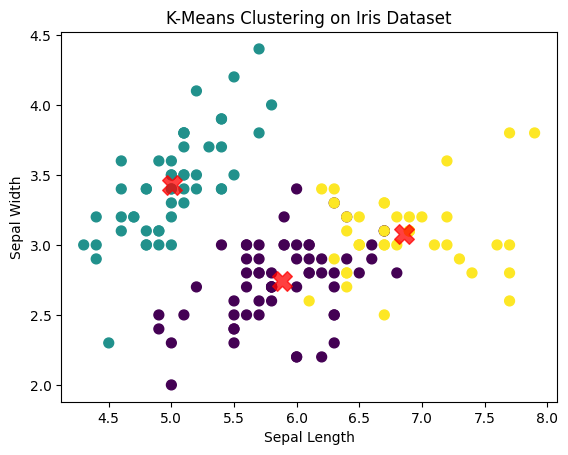

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

iris = datasets.load_iris()
X = iris.data
y_true = iris.target

kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, y_kmeans)
davies_bouldin = davies_bouldin_score(X, y_kmeans)
print("Silhouette Score: ", silhouette_avg)
print("Davies-Bouldin Score: ", davies_bouldin)

def relabel_clusters(y_true, y_pred):
    label_encoder = LabelEncoder()
    y_true_encoded = label_encoder.fit_transform(y_true)
    cm = confusion_matrix(y_true_encoded, y_pred)
    return np.argmax(cm, axis=1)

relabel_map = relabel_clusters(y_true, y_kmeans)
y_kmeans_mapped = np.array([relabel_map[label] for label in y_kmeans])

print("Confusion Matrix:\n", confusion_matrix(y_true, y_kmeans_mapped))
print("Classification Report:\n", classification_report(y_true, y_kmeans_mapped))


plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()


In [17]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data # Features
y = iris.target # Labels
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Create and fit the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
# Make predictions
y_pred_nb = nb_model.predict(X_test)
# Performance metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
confusion_nb = confusion_matrix(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)
# Display metrics
print("Naive Bayes Performance Metrics:")
print("Accuracy:", accuracy_nb)
print("Confusion Matrix:\n", confusion_nb)
print("Classification Report:\n", report_nb)

Naive Bayes Performance Metrics:
Accuracy: 0.9777777777777777
Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [18]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data # Features
y = iris.target # Labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and fit the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Performance metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
confusion_nb = confusion_matrix(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)

# Display metrics
print("Naive Bayes Performance Metrics:")
print("Accuracy:", accuracy_nb)
print("Confusion Matrix:\n", confusion_nb)
print("Classification Report:\n", report_nb)


Naive Bayes Performance Metrics:
Accuracy: 0.9777777777777777
Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [19]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
iris=datasets.load_iris()
X=iris.data
y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)
accuracy_dt=accuracy_score(y_test,y_pred_dt)
confusion_dt=confusion_matrix(y_test,y_pred_dt)
report_dt=classification_report(y_test,y_pred_dt)
print("Decision Tree Performance Metrics:")
print("Accuracy:",accuracy_dt)
print("Confusion Matrix:\n",confusion_dt)
print("Classification Report:\n",report_dt)


Decision Tree Performance Metrics:
Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [20]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error
iris=datasets.load_iris()
X_class=iris.data
y_class=iris.target
X_train_class,X_test_class,y_train_class,y_test_class=train_test_split(X_class,y_class,test_size=0.3,random_state=42)
knn_classifier=KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_class,y_train_class)
y_pred_class=knn_classifier.predict(X_test_class)
accuracy_class=accuracy_score(y_test_class,y_pred_class)
confusion_class=confusion_matrix(y_test_class,y_pred_class)
report_class=classification_report(y_test_class,y_pred_class)
print("KNN Classification Performance Metrics:")
print("Accuracy:",accuracy_class)
print("Confusion Matrix:\n",confusion_class)
print("Classification Report:\n",report_class)
boston=datasets.load_diabetes()
X_reg=boston.data
y_reg=boston.target
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(X_reg,y_reg,test_size=0.3,random_state=42)
knn_regressor=KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_reg,y_train_reg)
y_pred_reg=knn_regressor.predict(X_test_reg)
mse=mean_squared_error(y_test_reg,y_pred_reg)
print("KNN Regression Performance Metrics:")
print("Mean Squared Error:",mse)


KNN Classification Performance Metrics:
Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

KNN Regression Performance Metrics:
Mean Squared Error: 3222.117894736842


In [21]:
from collections import deque

def dfs(graph,start,visited=None):
    if visited is None:
        visited=set()
    visited.add(start)
    print(start,end=' ')
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph,neighbor,visited)

def bfs(graph,start):
    visited=set()
    queue=deque([start])
    visited.add(start)
    while queue:
        vertex=queue.popleft()
        print(vertex,end=' ')
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

# Example graph represented as an adjacency list
graph={
    'A':['B','C'],
    'B':['D','E'],
    'C':['F'],
    'D':[],
    'E':['F'],
    'F':[]
}

print("DFS:")
dfs(graph,'A')
print("\nBFS:")
bfs(graph,'A')


DFS:
A B D E F C 
BFS:
A B C D E F 

In [22]:
class Graph:
 def __init__(self):
  self.graph = {}
 def add_edge(self, u, v):
  if u not in self.graph:
   self.graph[u] = []
  self.graph[u].append(v)

 def get_neighbors(self, u):
  return self.graph.get(u, [])

def dfs(graph, start, visited=None):
 if visited is None:
  visited = set()
 visited.add(start)
 print(start, end=' ')

 for neighbor in graph.get_neighbors(start):
  if neighbor not in visited:
   dfs(graph, neighbor, visited)

from collections import deque

def bfs(graph, start):
 visited = set()
 queue = deque([start])
 visited.add(start)

 while queue:
  node = queue.popleft()
  print(node, end=' ')

  for neighbor in graph.get_neighbors(node):
   if neighbor not in visited:
    visited.add(neighbor)
    queue.append(neighbor)

# Example usage
g = Graph()
g.add_edge(1, 2)
g.add_edge(1, 3)
g.add_edge(2, 4)
g.add_edge(2, 5)
g.add_edge(3, 6)
g.add_edge(3, 7)
print("DFS Traversal:")
dfs(g, 1) # Start from node 1
print("\nBFS Traversal:")
bfs(g, 1) # Start from node 1


DFS Traversal:
1 2 4 5 3 6 7 
BFS Traversal:
1 2 3 4 5 6 7 

In [1]:
class Graph:
 def __init__(self):
  self.graph = {}
 def add_edge(self, u, v):
  self.graph.setdefault(u, []).append(v)

def dfs(graph, start, visited=None):
 if visited is None:
  visited = set()
 visited.add(start)
 print(start, end=' ')
 for neighbor in graph.graph.get(start, []):
  if neighbor not in visited:
   dfs(graph, neighbor, visited)

def bfs(graph, start):
 visited = set([start])
 queue = [start]
 while queue:
  node = queue.pop(0)
  print(node, end=' ')
  for neighbor in graph.graph.get(node, []):
   if neighbor not in visited:
    visited.add(neighbor)
    queue.append(neighbor)

g = Graph()
for u, v in [(1, 2), (1, 3), (2, 4), (2, 5), (3, 6), (3, 7)]:
 g.add_edge(u, v)
print("DFS Traversal:")
dfs(g, 1)
print("\nBFS Traversal:")
bfs(g, 1)


DFS Traversal:
1 2 4 5 3 6 7 
BFS Traversal:
1 2 3 4 5 6 7 

In [7]:
class Graph:
    def __init__(self):
        self.graph={}
    def add_edge(self,u,v):
        self.graph.setdefault(u,[]).append(v)